### Import Packages

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from parentHelpers import *
from loanPipelineHelpers import *
from regression import *
# from helperProjectDriver import *
# from helperProjectAlamo import *
from databaseHelpers import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Query and clean up the dataframe

In [3]:
query = """
        SELECT * FROM [MH_Deal_Performance] 
        WHERE DEAL in ('cmha22m1', 'twpt20m1', 'CMHA19M1')
        """

# df_raw = connect_db(query)
# df = df_raw.copy()

In [4]:
cmha19m1 = '''
            SELECT 
                    *
                ,   CASE WHEN UNIQUE_ID IN
                                            (
                                                SELECT UNIQUE_ID
                                                FROM [ConsumerLoans].[dbo].[MH_Deal_Performance]
                                                WHERE 
                                                    DEAL = 'CMHA19M1'
                                                and rpt_Date='20260425'
                                                and ai_appR_VALUE_orig>0
                                                /* For CMHA19M1, all the loans with >0 AI_APPR_VALUE_ORIG in the last snapshot are land home loans. */
                                            ) THEN 1 ELSE 0 END AS Is_Land_Home_Loan
                                            FROM 
                [ConsumerLoans].[dbo].[MH_Deal_Performance]
            WHERE 
                DEAL = 'CMHA19M1'
            '''


cmha22m1 = '''
            SELECT 
                    * 
                ,   CASE WHEN PROPCODE = 'Chattel' THEN 0 ELSE 1 END AS Is_Land_Home_Loan
            FROM 
                [ConsumerLoans].[dbo].[MH_Deal_Performance]
            WHERE 
                DEAL = 'CMHA22M1'
            '''


twpt20m1 = '''
            SELECT 
                    * 
                ,   CASE WHEN PROPCODE = 'Other/Unknown' THEN 0 ELSE 1 END AS Is_Land_Home_Loan
            FROM 
                [ConsumerLoans].[dbo].[MH_Deal_Performance]
            WHERE 
                DEAL = 'TWPT20M1'
            '''

cmha24m1 = '''
            SELECT 
                    * 
                ,   CASE WHEN ORIGAMORBALLN < 360 THEN 0 ELSE 1 END AS Is_Land_Home_Loan
            FROM [ConsumerLoans].[dbo].[MH_Deal_Performance]
            WHERE DEAL = 'CMHA24M1'	
            '''


In [5]:
df_cmha19m1 = connect_db(cmha19m1)
df_cmha22m1 = connect_db(cmha22m1)
# df_twpt20m1 = connect_db(twpt20m1)

df_cmha24m1 = connect_db(cmha24m1)
df_chattel = pd.concat([df_cmha19m1, df_cmha22m1, df_cmha24m1], ignore_index=True, sort=False)

c:\Users\YuemengZhang\anaconda3\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\YuemengZhang\anaconda3\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\YuemengZhang\anaconda3\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


### Clean Data Set

In [137]:
df_chattel['RPT_DATE'] = pd.to_datetime(df_chattel['RPT_DATE'])
df_chattel['TOTAL_LOSS_EST'] = df_chattel[['LOSS_PRIOR_TO_PAYOFF', 'LOSS_ON_PAYOFF', 'LOSS_AFTER_PAYOFF']].sum(axis=1)

# df_chattel, audit = fill_from_latest_nonblank_snapshot(
#     df_chattel,
#     id_col="UNIQUE_ID",
#     snapshot_col="RPT_DATE",
#     fill_col="ORIGLTV",
# )

df_chattel, audit = fill_from_latest_nonblank_snapshot(
    df_chattel,
    id_col="UNIQUE_ID",
    snapshot_col="RPT_DATE",
    fill_col="AI_ORIG_DTI",
)

def estimate_dpd(x):
    if x == '30':
        return 31
    elif x == '60':
        return 61
    elif x == 'NULL':
        return 0
    elif x == 'FC':
        return 121
    elif x == '90+':
        return 91
    elif x == 'REO':
        return 151
    elif x == 'Bnkrpt':
        return 0
    else:
        return 0
    
df_chattel['DPD ESTIMATE'] = df_chattel['DELINQ'].apply(lambda x: estimate_dpd(x))

df_chattel["Vintage"] = (
    pd.to_datetime(df_chattel["ISSUE_DATE"])
    .dt.to_period("M")
    # .dt.to_timestamp("M")
)

df_chattel["IS_PERFECT_PAY"] = df_chattel["AI_PAYSTATUS_PRE_DEAL_ISSUANCE"].apply(is_perfect_pay)

,UNIQUE_ID,AI_ORIG_DTI_latest_nonblank_value,AI_ORIG_DTI_source_snapshot_date,latest_snapshot_date,AI_ORIG_DTI_source_not_latest_snapshot
0,LNCMHA19M1-000000001600741,41.532,2026-04-25,2026-04-25,False
1,LNCMHA19M1-000000001701860,39.553,2026-04-25,2026-04-25,False
2,LNCMHA19M1-000000001702301,43.784,2026-04-25,2026-04-25,False
3,LNCMHA19M1-000000001702629,44.546,2026-04-25,2026-04-25,False
4,LNCMHA19M1-000000001703242,28.634,2026-04-25,2026-04-25,False
...,...,...,...,...,...
4835,LNCMHA24M1-000000024242227,36.173,2026-04-25,2026-04-25,False
4836,LNCMHA24M1-000000024242774,38.051,2026-04-25,2026-04-25,False
4837,LNCMHA24M1-000000024243150,47.977,2026-04-25,2026-04-25,False
4838,LNCMHA24M1-000000024243334,39.161,2026-04-25,2026-04-25,False


In [138]:
df_chattel['AI_ORIG_DTI'] = df_chattel['AI_ORIG_DTI'].apply(lambda x: x if isinstance(x, float) else np.nan)

In [139]:
cmha19m1_close_date = '2019-10-25'
cmha22m1_close_date = '2022-07-25'
cmha24m1_close_date = '2024-10-25'
df_chattel['RPT_DATE'] = pd.to_datetime(df_chattel['RPT_DATE'])
df_chattel['Months since Deal Close'] = df_chattel.apply(lambda row: (row['RPT_DATE'] - pd.to_datetime(cmha19m1_close_date)).days // 30 if row['DEAL'] == 'cmha19m1' else 
                                                            (row['RPT_DATE'] - pd.to_datetime(cmha22m1_close_date)).days // 30 if row['DEAL'] == 'cmha22m1' else 
                                                            (row['RPT_DATE'] - pd.to_datetime(cmha24m1_close_date)).days // 30 if row['DEAL'] == 'cmha24m1' else float('nan'),
                                                            axis=1)

In [140]:
df_chattel['Deal Close Vintage'] = df_chattel.apply(lambda row: pd.to_datetime(cmha19m1_close_date) if row['DEAL'] == 'cmha19m1' else 
                                                        pd.to_datetime(cmha22m1_close_date) if row['DEAL'] == 'cmha22m1' else 
                                                        pd.to_datetime(cmha24m1_close_date) if row['DEAL'] == 'cmha24m1' else pd.NaT, 
                                                        axis=1)

In [141]:
display(df_chattel)

,DEAL,RPT_DATE,ITEM,IDNUMBER,UNIQUE_ID,ORIGBALANCE,CURBALANCE,CUR_CONTRIB_BALANCE,GROSSCOUPON,AMORT,...,TOTAL_LOSS_EST,AI_ORIG_DTI_was_filled,AI_ORIG_DTI_fill_source_snapshot_date,AI_ORIG_DTI_fill_source_not_latest_snapshot,DPD ESTIMATE,Vintage,IS_PERFECT_PAY,Months since Deal Close,Deal Close Vintage,Default
0,cmha19m1,2020-12-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,85830.68,85830.68,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,14,2019-10-25,0.0
1,cmha19m1,2022-03-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,83759.10,83759.10,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,29,2019-10-25,0.0
2,cmha19m1,2020-10-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,86089.77,86089.77,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,12,2019-10-25,0.0
3,cmha19m1,2020-08-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,86345.02,86345.02,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,10,2019-10-25,0.0
4,cmha19m1,2020-06-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,86596.50,86596.50,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,8,2019-10-25,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276727,cmha24m1,2025-09-25,926,24231801,LNCMHA24M1-000000024231801,125386.0,123424.61,123424.61,8.25,None,...,0.0,False,2026-04-25,False,0,2024-06,True,11,2024-10-25,0.0
276728,cmha24m1,2025-09-25,927,24231807,LNCMHA24M1-000000024231807,131694.0,130036.95,130036.95,8.25,None,...,0.0,False,2026-04-25,False,0,2024-06,True,11,2024-10-25,0.0
276729,cmha24m1,2025-09-25,928,24231925,LNCMHA24M1-000000024231925,107826.0,106517.89,106517.89,9.00,None,...,0.0,False,2026-04-25,False,0,2024-07,True,11,2024-10-25,0.0
276730,cmha24m1,2024-12-25,347,23198948,LNCMHA24M1-000000023198948,211875.0,210971.65,210971.65,10.80,None,...,0.0,False,2026-04-25,False,0,2024-05,True,2,2024-10-25,NaN


In [153]:
df_loss[df_loss['ACCUMLOSS_AMT'] > 0]

,DEAL,RPT_DATE,ITEM,IDNUMBER,UNIQUE_ID,ORIGBALANCE,CURBALANCE,CUR_CONTRIB_BALANCE,GROSSCOUPON,AMORT,...,AI_ORIG_DTI_fill_source_snapshot_date,AI_ORIG_DTI_fill_source_not_latest_snapshot,DPD ESTIMATE,Vintage,IS_PERFECT_PAY,Months since Deal Close,Deal Close Vintage,Default,CUM_LOSS,loss_amount
10322,cmha19m1,2026-01-25,67,1707313,LNCMHA19M1-000000001707313,67573.0,0.0,0.0,9.472,None,...,2026-04-25,False,0,2017-08,True,76,2019-10-25,27938.12,0.0,0.0
10377,cmha19m1,2025-12-25,67,1707313,LNCMHA19M1-000000001707313,67573.0,0.0,0.0,9.472,None,...,2026-04-25,False,0,2017-08,True,75,2019-10-25,27938.12,0.0,0.0
10408,cmha19m1,2025-11-25,67,1707313,LNCMHA19M1-000000001707313,67573.0,0.0,0.0,9.472,None,...,2026-04-25,False,0,2017-08,True,74,2019-10-25,27938.12,0.0,0.0
10461,cmha19m1,2026-03-25,67,1707313,LNCMHA19M1-000000001707313,67573.0,0.0,0.0,9.472,None,...,2026-04-25,False,0,2017-08,True,78,2019-10-25,27938.12,0.0,0.0
10463,cmha19m1,2026-02-25,67,1707313,LNCMHA19M1-000000001707313,67573.0,0.0,0.0,9.472,None,...,2026-04-25,False,0,2017-08,True,77,2019-10-25,27938.12,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262595,cmha24m1,2026-03-25,937,24232973,LNCMHA24M1-000000024232973,89815.0,0.0,0.0,10.300,None,...,2026-04-25,False,0,2024-07,True,17,2024-10-25,61264.65,0.0,0.0
268315,cmha24m1,2025-12-25,937,24232973,LNCMHA24M1-000000024232973,89815.0,0.0,0.0,10.300,None,...,2026-04-25,False,0,2024-07,True,14,2024-10-25,61264.65,0.0,0.0
272465,cmha24m1,2026-04-25,937,24232973,LNCMHA24M1-000000024232973,89815.0,0.0,0.0,10.300,None,...,2026-04-25,False,0,2024-07,True,18,2024-10-25,61264.65,0.0,0.0
274111,cmha24m1,2026-01-25,937,24232973,LNCMHA24M1-000000024232973,89815.0,0.0,0.0,10.300,None,...,2026-04-25,False,0,2024-07,True,15,2024-10-25,61264.65,0.0,0.0


In [155]:
df_loss[df_loss['UNIQUE_ID'] == 'LNCMHA19M1-000000001707313'][['UNIQUE_ID', 'RPT_DATE', 'CURBALANCE', 'DELINQ', 'ACCUMLOSS_AMT', 'DPD ESTIMATE', 'CUM_LOSS', 'loss_amount']]

,UNIQUE_ID,RPT_DATE,CURBALANCE,DELINQ,ACCUMLOSS_AMT,DPD ESTIMATE,CUM_LOSS,loss_amount
10580,LNCMHA19M1-000000001707313,2019-11-25,64835.90,None,NaN,0,0.0,0.0
10536,LNCMHA19M1-000000001707313,2019-12-25,64719.04,None,NaN,0,0.0,0.0
10537,LNCMHA19M1-000000001707313,2020-01-25,64601.26,None,NaN,0,0.0,0.0
10539,LNCMHA19M1-000000001707313,2020-02-25,64362.90,None,NaN,0,0.0,0.0
10538,LNCMHA19M1-000000001707313,2020-03-25,64362.90,None,NaN,0,0.0,0.0
...,...,...,...,...,...,...,...,...
10377,LNCMHA19M1-000000001707313,2025-12-25,0.00,None,27938.12,0,0.0,0.0
10408,LNCMHA19M1-000000001707313,2025-11-25,0.00,None,27938.12,0,0.0,0.0
10461,LNCMHA19M1-000000001707313,2026-03-25,0.00,None,27938.12,0,0.0,0.0
10463,LNCMHA19M1-000000001707313,2026-02-25,0.00,None,27938.12,0,0.0,0.0


### CDR

In [162]:
df_loss = df_chattel.copy()

# # cdr_df = df_chattel.copy()
# df_loss['CUM_LOSS'] = df_loss.apply(lambda x: x['CURBALANCE'] if x['DPD ESTIMATE'] > 120 else 0, axis=1)

cum_loss_col = "ACCUMLOSS_AMT"      # replace with your cumulative loss column
loan_id_col = "UNIQUE_ID"
mob_col = "AGE"

df_loss[cum_loss_col] = pd.to_numeric(df_loss[cum_loss_col], errors="coerce").fillna(0)

df_loss = df_loss.sort_values([loan_id_col, mob_col])

df_loss["_has_loss"] = df_loss[cum_loss_col] > 0

df_loss["_prior_has_loss"] = (
    df_loss
    .groupby(loan_id_col)["_has_loss"]
    .transform(lambda s: s.cummax().shift(fill_value=False))
)

df_loss["loss_amount"] = np.where(
    df_loss["_has_loss"] & ~df_loss["_prior_has_loss"],
    df_loss[cum_loss_col],
    0
)

df_loss = df_loss.drop(columns=["_has_loss", "_prior_has_loss"])

In [168]:
cdr_df = df_loss.copy()
cdr_df["default_amount"] = pd.to_numeric(cdr_df['loss_amount'], errors="coerce").fillna(0)
cdr_df["CURBALANCE"] = pd.to_numeric(cdr_df["CURBALANCE"], errors="coerce")
cdr_df["ORIGBALANCE"] = pd.to_numeric(cdr_df["ORIGBALANCE"], errors="coerce")

cdr_df = cdr_df.sort_values(["UNIQUE_ID", "AGE"])

cdr_df["bom_balance"] = (
    cdr_df
    .groupby("UNIQUE_ID")["CURBALANCE"]
    .shift(0)
)

# cdr_df["bom_balance"] = cdr_df["bom_balance"].fillna(cdr_df["ORIGBALANCE"])

In [169]:
cdr_curve = (
    cdr_df
    .groupby(["Deal Close Vintage", "Months since Deal Close"])
    .agg(
        default_amount=("default_amount", "sum"),
        bom_balance=("bom_balance", "sum"),
    )
    .reset_index()
)

cdr_curve["MDR"] = cdr_curve["default_amount"] / cdr_curve["bom_balance"]
cdr_curve["CDR"] = 1 - (1 - cdr_curve["MDR"]) ** 12

In [170]:
cdr_pivot = cdr_curve.pivot(
    index="Months since Deal Close",
    columns="Deal Close Vintage",
    values="CDR"
)

In [171]:
cdr_pivot * 100

Deal Close Vintage,2019-10-25,2022-07-25,2024-10-25
Months since Deal Close,,,
-2,NaN,NaN,0.0
-1,0.000000,0.0,0.0
0,0.000000,0.0,0.0
1,0.000000,0.0,0.0
2,0.000000,0.0,0.0
...,...,...,...
75,1.394110,NaN,NaN
76,1.756430,NaN,NaN
77,3.108382,NaN,NaN


<AxesSubplot:xlabel='Months since Deal Close'>

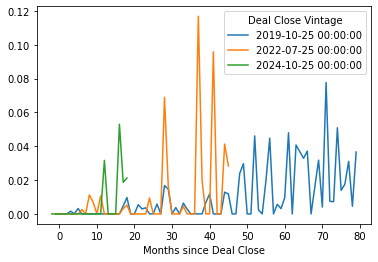

In [172]:
cdr_pivot.plot()

In [150]:
df_chattel.head()

,DEAL,RPT_DATE,ITEM,IDNUMBER,UNIQUE_ID,ORIGBALANCE,CURBALANCE,CUR_CONTRIB_BALANCE,GROSSCOUPON,AMORT,...,TOTAL_LOSS_EST,AI_ORIG_DTI_was_filled,AI_ORIG_DTI_fill_source_snapshot_date,AI_ORIG_DTI_fill_source_not_latest_snapshot,DPD ESTIMATE,Vintage,IS_PERFECT_PAY,Months since Deal Close,Deal Close Vintage,Default
0,cmha19m1,2020-12-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,85830.68,85830.68,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,14,2019-10-25,0.0
1,cmha19m1,2022-03-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,83759.10,83759.10,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,29,2019-10-25,0.0
2,cmha19m1,2020-10-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,86089.77,86089.77,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,12,2019-10-25,0.0
3,cmha19m1,2020-08-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,86345.02,86345.02,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,10,2019-10-25,0.0
4,cmha19m1,2020-06-25,1,1600741,LNCMHA19M1-000000001600741,90149.0,86596.50,86596.50,8.99,None,...,0.0,False,2026-04-25,False,0,2017-09,True,8,2019-10-25,0.0


### D30+

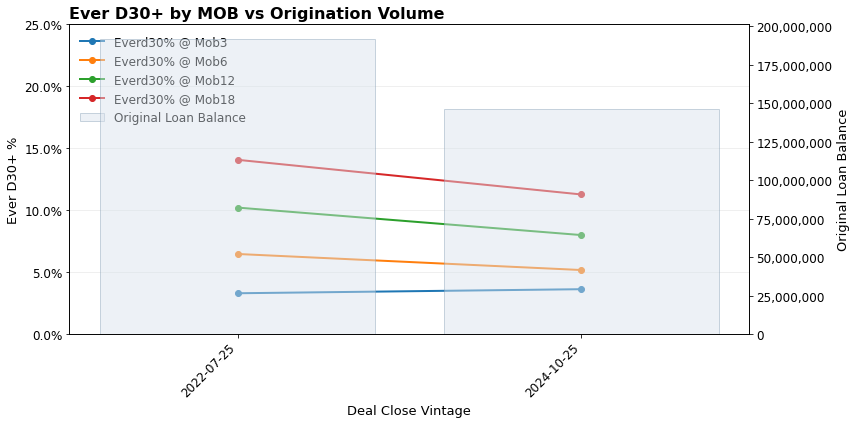

In [187]:
age_cutoff = [3, 6, 12, 18]
dpd_col_name = "DPD ESTIMATE"
default_col_name = 'TOTAL_LOSS_EST'
dpd_num = 30
# mob_col_name = 'AGE'
mob_col_name = 'Months since Deal Close'
loan_id_col_name = "UNIQUE_ID"
original_bal_col_name = 'CURBALANCE'
# vintage_col_name = 'Vintage'
vintage_col_name = 'Deal Close Vintage'
filter_to_orig_data = True
# filter_mask = (df_chattel['DEAL'] == 'cmha19m1')& (df_chattel['RPT_DATE'] == '2019-11-25')
# filter_mask = (df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25')
# filter_mask = (df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25')

filter_mask = (  
                ((df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25'))
               | ((df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25')))

# filter_mask = (  
#                 ((df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25') & (df_chattel['AGE'] <= 5))
#                | ((df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25') & (df_chattel['AGE'] <= 5)))
#             #    | ((df_chattel['DEAL'] == 'cmha19m1')& (df_chattel['RPT_DATE'] == '2019-11-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 0)))
# you need to find the first pay day to filter


value_cols = []
for age in age_cutoff:
    everd30_pct_col = "EverD{}% @ MOB{}".format(dpd_num, age)
    value_cols.append(everd30_pct_col)

out, ever_dq_co = create_everDQ_MOBn_chart(df_chattel, 
                             age_cutoff = age_cutoff, 
                             dpd_col_name = dpd_col_name, 
                             default_col_name = default_col_name,
                             dpd_num = dpd_num, 
                             mob_col_name = mob_col_name, 
                             loan_id_col_name = loan_id_col_name,
                             original_bal_col_name = original_bal_col_name,
                             vintage_col_name = vintage_col_name,
                             filter_to_orig_data = True,
                             filter_mask = filter_mask
                             )

everd30_charts = plot_metric_vs_volume(
                                        out.reset_index(),
                                        value_cols=value_cols,
                                        right_value_cols=None,
                                        volume_col=original_bal_col_name,
                                        x_col=vintage_col_name,
                                        title="Ever D{}+ by MOB vs Origination Volume".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors="#e70f3e",
                                        volume_display="right_axis",  # switch to "right_axis" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=0.25,
                                    )


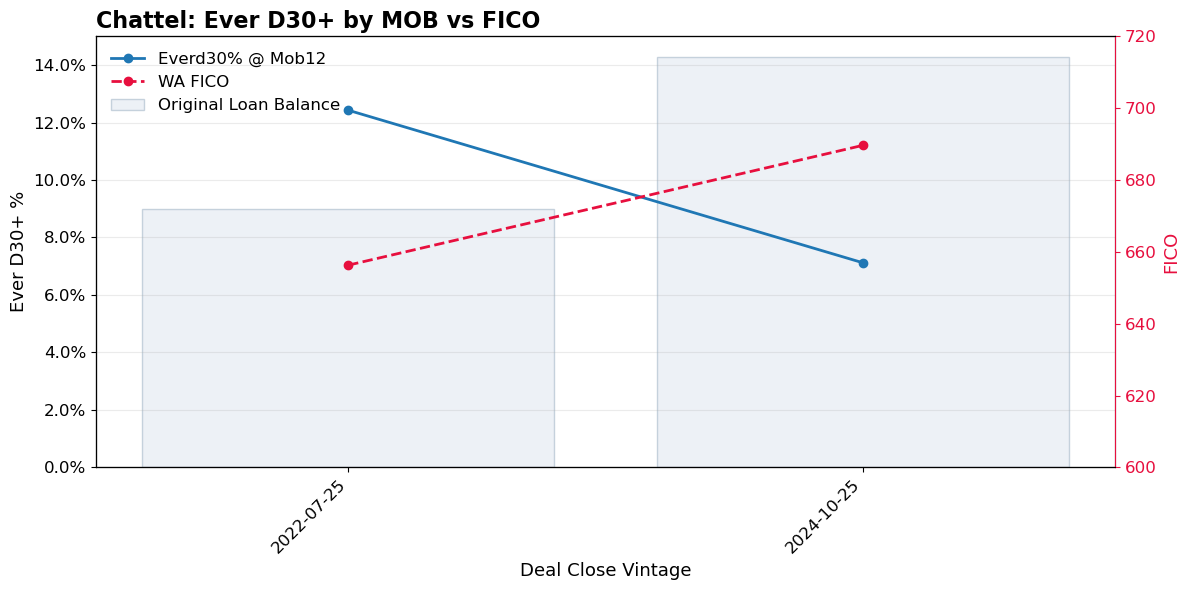

In [1069]:
age_cutoff = [12]
dpd_col_name = "DPD ESTIMATE"
default_col_name = 'TOTAL_LOSS_EST'
dpd_num = 30
# mob_col_name = 'AGE'
mob_col_name = 'Months since Deal Close'
loan_id_col_name = "UNIQUE_ID"
original_bal_col_name = 'CURBALANCE'
# vintage_col_name = 'Vintage'
vintage_col_name = 'Deal Close Vintage'
filter_to_orig_data = True
# filter_mask = (df_chattel['DEAL'] == 'cmha19m1')& (df_chattel['RPT_DATE'] == '2019-11-25')
# filter_mask = (df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25')
# filter_mask = (df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25')
filter_mask = ( 
                ((df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 0))
               | ((df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 0)))
            #    | ((df_chattel['DEAL'] == 'cmha19m1')& (df_chattel['RPT_DATE'] == '2019-11-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 0)))


value_cols = []
for age in age_cutoff:
    everd30_pct_col = "EverD{}% @ MOB{}".format(dpd_num, age)
    value_cols.append(everd30_pct_col)

out, ever_dq_co = create_everDQ_MOBn_chart(df_chattel, 
                             age_cutoff = age_cutoff, 
                             dpd_col_name = dpd_col_name, 
                             default_col_name = default_col_name,
                             dpd_num = dpd_num, 
                             mob_col_name = mob_col_name, 
                             loan_id_col_name = loan_id_col_name,
                             original_bal_col_name = original_bal_col_name,
                             vintage_col_name = vintage_col_name,
                             filter_to_orig_data = True,
                             filter_mask = filter_mask
                             )

extra_wa_cols = [
    "FICO",
    "ORIGLTV",
    "AI_ORIG_DTI",
    "ORIGBALANCE",
    "ORIGAMORBALLN"
]

extra_avg_cols = [
    "ORIGBALANCE"
    # "ORIGAMORBALLN",
    # "AI_ORIG_DTI",
]

for col in extra_wa_cols:
    wa_col = (
        ever_dq_co
        .assign(
            _value=pd.to_numeric(ever_dq_co[col], errors="coerce"),
            _weight=to_numeric_amount(ever_dq_co[original_bal_col_name]),
        )
        .dropna(subset=["_value", "_weight"])
        .query("_weight > 0")
        .groupby(vintage_col_name)
        .apply(lambda g: np.average(g["_value"], weights=g["_weight"]))
        .rename(f"WA {col}")
    )

    out = out.join(wa_col)

for col in extra_avg_cols:
    avg_col = (
        ever_dq_co
        .assign(_value=pd.to_numeric(ever_dq_co[col], errors="coerce"))
        .groupby(vintage_col_name)["_value"]
        .mean()
        .rename(f"Avg {col}")
    )

    out = out.join(avg_col)

everd30_charts = plot_metric_vs_volume(
                                        out.reset_index(),
                                        value_cols=value_cols,
                                        right_value_cols='WA FICO',
                                        volume_col=original_bal_col_name,
                                        x_col=vintage_col_name,
                                        title="Chattel: Ever D{}+ by MOB vs FICO".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="FICO",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors="#e70f3e",
                                        volume_display="background",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=0.15,
                                        right_y_min = 600,
                                        right_y_max = 720
                                    )

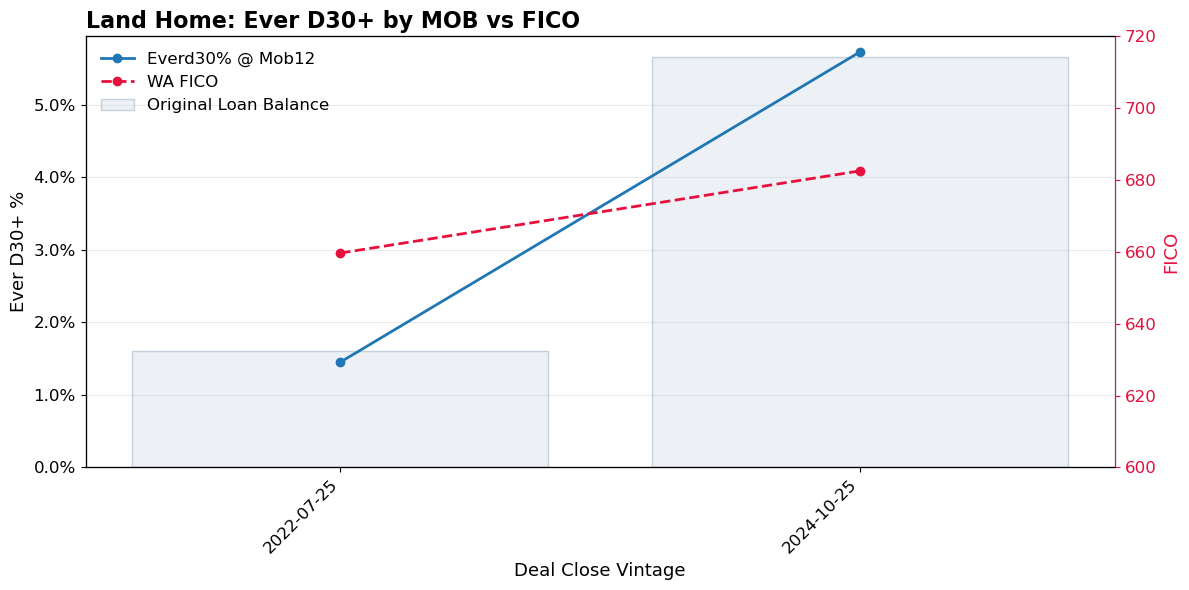

In [1070]:
age_cutoff = [12]
dpd_col_name = "DPD ESTIMATE"
default_col_name = 'TOTAL_LOSS_EST'
dpd_num = 30
# mob_col_name = 'AGE'
mob_col_name = 'Months since Deal Close'
loan_id_col_name = "UNIQUE_ID"
original_bal_col_name = 'CURBALANCE'
vintage_col_name = 'Deal Close Vintage'
# vintage_col_name = 'Vintage'
filter_to_orig_data = True
# filter_mask = (df_chattel['DEAL'] == 'cmha19m1')& (df_chattel['RPT_DATE'] == '2019-11-25')
# filter_mask = (df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25')
# filter_mask = (df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25')
filter_mask = (  
                ((df_chattel['DEAL'] == 'cmha22m1')& (df_chattel['RPT_DATE'] == '2022-08-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 1))
               | ((df_chattel['DEAL'] == 'cmha24m1')& (df_chattel['RPT_DATE'] == '2024-10-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 1)))
            #    | ((df_chattel['DEAL'] == 'cmha19m1')& (df_chattel['RPT_DATE'] == '2019-11-25') & (df_chattel['AGE'] <= 5) & (df_chattel['Is_Land_Home_Loan'] == 1)))
# you need to find the first pay day to filter


value_cols = []
for age in age_cutoff:
    everd30_pct_col = "EverD{}% @ MOB{}".format(dpd_num, age)
    value_cols.append(everd30_pct_col)

out_land_home, ever_dq_co_land_home = create_everDQ_MOBn_chart(df_chattel, 
                             age_cutoff = age_cutoff, 
                             dpd_col_name = dpd_col_name, 
                             default_col_name = default_col_name,
                             dpd_num = dpd_num, 
                             mob_col_name = mob_col_name, 
                             loan_id_col_name = loan_id_col_name,
                             original_bal_col_name = original_bal_col_name,
                             vintage_col_name = vintage_col_name,
                             filter_to_orig_data = True,
                             filter_mask = filter_mask
                             )

# extra_wa_cols = [
#     "FICO",
#     "ORIGLTV",
#     "AI_ORIG_DTI",
#     'ORIGBALANCE'
# ]

for col in extra_wa_cols:
    wa_col = (
        ever_dq_co_land_home
        .assign(
            _value=pd.to_numeric(ever_dq_co_land_home[col], errors="coerce"),
            _weight=to_numeric_amount(ever_dq_co_land_home[original_bal_col_name]),
        )
        .dropna(subset=["_value", "_weight"])
        .query("_weight > 0")
        .groupby(vintage_col_name)
        .apply(lambda g: np.average(g["_value"], weights=g["_weight"]))
        .rename(f"WA {col}")
    )

    out_land_home = out_land_home.join(wa_col)


for col in extra_avg_cols:
    avg_col = (
        ever_dq_co_land_home
        .assign(_value=pd.to_numeric(ever_dq_co[col], errors="coerce"))
        .groupby(vintage_col_name)["_value"]
        .mean()
        .rename(f"Avg {col}")
    )

    out_land_home = out_land_home.join(avg_col)

everd30_charts = plot_metric_vs_volume(
                                        out_land_home.reset_index(),
                                        value_cols=value_cols,
                                        right_value_cols='WA FICO',
                                        volume_col=original_bal_col_name,
                                        x_col=vintage_col_name,
                                        title="Land Home: Ever D{}+ by MOB vs FICO".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="FICO",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors="#e70f3e",
                                        volume_display="background",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=None,
                                        right_y_min = 600,
                                        right_y_max = 720
                                    )

In [1071]:
output = out.join(out_land_home, lsuffix="_chattel", rsuffix="_land_home")

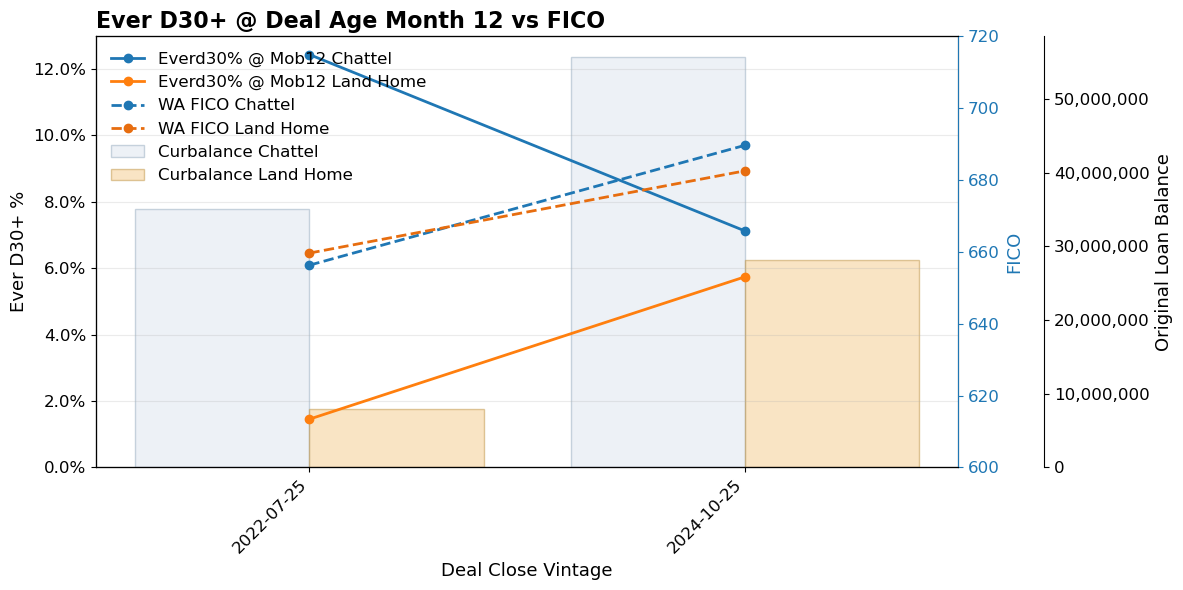

In [1074]:
everd30_charts = plot_metric_vs_volume(
                                        output.reset_index(),
                                        value_cols=['EverD30% @ MOB12_chattel', 'EverD30% @ MOB12_land_home'],
                                        right_value_cols=['WA FICO_chattel', 'WA FICO_land_home'],
                                        volume_col=['CURBALANCE_chattel', 'CURBALANCE_land_home'],
                                        volume_color=["#d9e2ec", "#f2c57c"],
                                        volume_edge_color=["#8aa2b8", "#b88932"],

                                        x_col=vintage_col_name,
                                        title="Ever D{}+ @ Deal Age Month 12 vs FICO".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="FICO",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors=["#1f77b4", "#e76d0f"],
                                        volume_display="right_axis",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=None,
                                        right_y_min = 600,
                                        right_y_max = 720
                                    )

In [832]:
# output

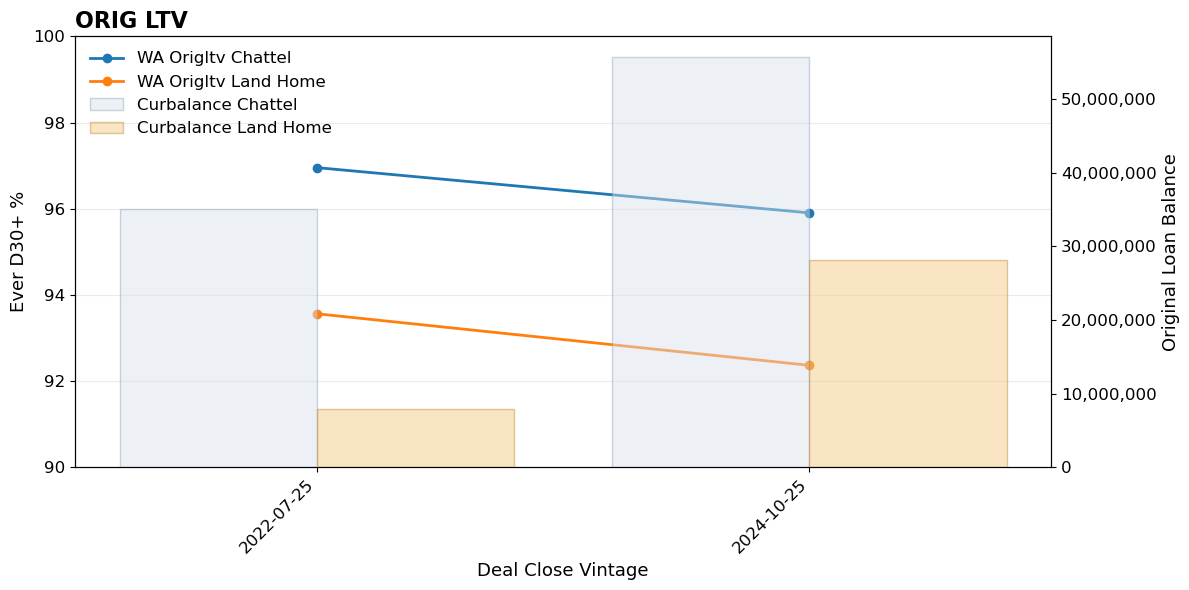

In [1086]:
# output = out.join(out_land_home, lsuffix="_chattel", rsuffix="_land_home")
everd30_charts = plot_metric_vs_volume(
                                        output.reset_index(),
                                        value_cols=['WA ORIGLTV_chattel', 'WA ORIGLTV_land_home'],
                                        right_value_cols=[],
                                        volume_col=['CURBALANCE_chattel', 'CURBALANCE_land_home'],
                                        volume_color=["#d9e2ec", "#f2c57c"],
                                        volume_edge_color=["#8aa2b8", "#b88932"],

                                        x_col=vintage_col_name,
                                        title="ORIG LTV".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="ORIGLTV",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="integer",
                                        right_y_formatter="integer",
                                        right_colors=["#1f77b4", "#e76d0f"],
                                        volume_display="right_axis",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=90,
                                        value_y_max=100,
                                        right_y_min = 90,
                                        right_y_max = 100
                                    )

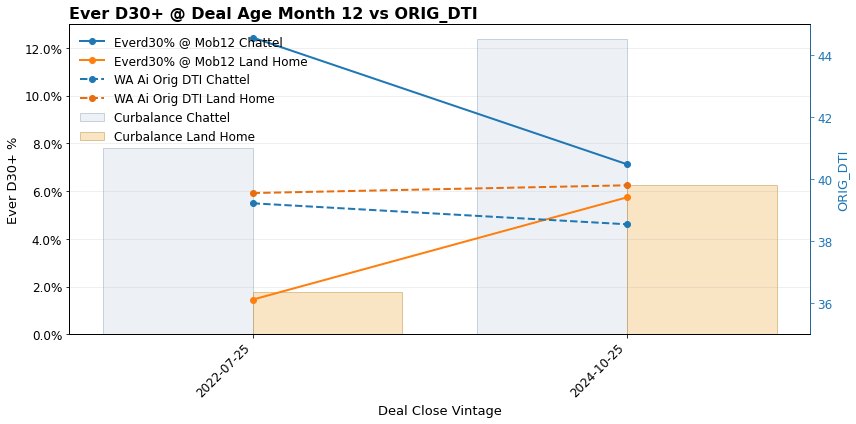

In [653]:
# output = out.join(out_land_home, lsuffix="_chattel", rsuffix="_land_home")
everd30_charts = plot_metric_vs_volume(
                                        output.reset_index(),
                                        value_cols=['EverD30% @ MOB12_chattel', 'EverD30% @ MOB12_land_home'],
                                        right_value_cols=['WA AI_ORIG_DTI_chattel', 'WA AI_ORIG_DTI_land_home'],
                                        volume_col=['CURBALANCE_chattel', 'CURBALANCE_land_home'],
                                        volume_color=["#d9e2ec", "#f2c57c"],
                                        volume_edge_color=["#8aa2b8", "#b88932"],

                                        x_col=vintage_col_name,
                                        title="Ever D{}+ @ Deal Age Month 12 vs ORIG_DTI".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="ORIG_DTI",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors=["#1f77b4", "#e76d0f"],
                                        volume_display="background",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=None,
                                        right_y_min = 35,
                                        right_y_max = 45
                                    )

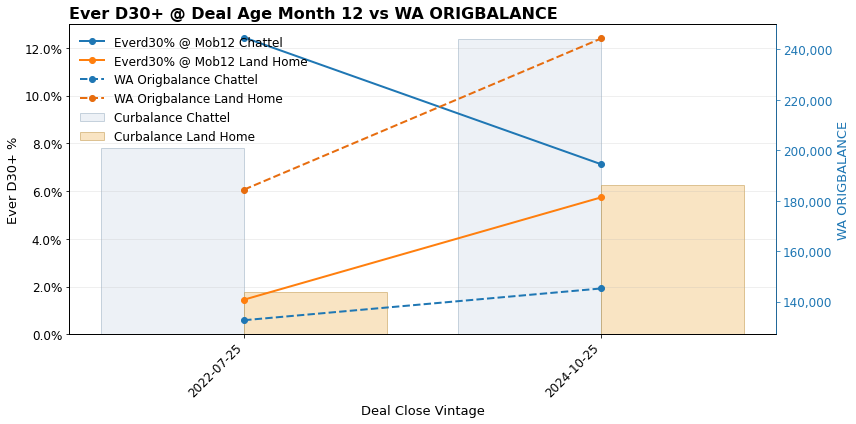

In [654]:
# output = out.join(out_land_home, lsuffix="_chattel", rsuffix="_land_home")
everd30_charts = plot_metric_vs_volume(
                                        output.reset_index(),
                                        value_cols=['EverD30% @ MOB12_chattel', 'EverD30% @ MOB12_land_home'],
                                        right_value_cols=['WA ORIGBALANCE_chattel', 'WA ORIGBALANCE_land_home'],
                                        volume_col=['CURBALANCE_chattel', 'CURBALANCE_land_home'],
                                        volume_color=["#d9e2ec", "#f2c57c"],
                                        volume_edge_color=["#8aa2b8", "#b88932"],

                                        x_col=vintage_col_name,
                                        title="Ever D{}+ @ Deal Age Month 12 vs WA ORIGBALANCE".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="WA ORIGBALANCE",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors=["#1f77b4", "#e76d0f"],
                                        volume_display="background",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=None,
                                        # right_y_min = 35,
                                        # right_y_max = 45
                                    )

In [656]:
# # output = out.join(out_land_home, lsuffix="_chattel", rsuffix="_land_home")
# everd30_charts = plot_metric_vs_volume(
#                                         output.reset_index(),
#                                         value_cols=['EverD30% @ MOB12_chattel', 'EverD30% @ MOB12_land_home'],
#                                         right_value_cols=['Avg ORIGBALANCE_chattel', 'Avg ORIGBALANCE_land_home'],
#                                         volume_col=['CURBALANCE_chattel', 'CURBALANCE_land_home'],
#                                         volume_color=["#d9e2ec", "#f2c57c"],
#                                         volume_edge_color=["#8aa2b8", "#b88932"],

#                                         x_col=vintage_col_name,
#                                         title="Ever D{}+ @ Deal Age Month 12 vs WA ORIGBALANCE".format(dpd_num),
#                                         x_label=format_column_label(vintage_col_name),
#                                         value_ylabel="Ever D{}+ %".format(dpd_num),
#                                         right_ylabel="WA ORIGBALANCE",
#                                         volume_ylabel="Original Loan Balance",
#                                         value_y_formatter="percent",
#                                         right_y_formatter="integer",
#                                         right_colors=["#1f77b4", "#e76d0f"],
#                                         volume_display="background",  # switch to "right_axis" or "background" or "none"
#                                         figsize=(12, 6),
#                                         show=True,
#                                         value_y_min=0,
#                                         value_y_max=None,
#                                         # right_y_min = 35,
#                                         # right_y_max = 45
#                                     )

In [643]:
# output.to_excel("chattel_land_home_compare.xlsx", index=True)

In [369]:
# ever_dq_co[ever_dq_co["AI_ORIG_DTI"].apply(lambda x: False if isinstance(x, float) else True)]

In [474]:
# display(ever_dq_co)

In [188]:
ever_dq_co_select = ever_dq_co[['UNIQUE_ID',
                                'DEAL',
                                'ORIGBALANCE', 
                                'GROSSCOUPON', 
                                'ORIGAMORBALLN', 
                                'AGE', 
                                'NETCOUPON', 
                                'STATE', 
                                'REGION', 
                                # 'ORIGLTV', 
                                'LTV',
                                # 'AI_CUR_LTV', 
                                # 'AI_FICO_AT_LOAN_ORIGINATION', 
                                'FICO',
                                'AI_ORIG_DTI',
                                'IS_PERFECT_PAY',
                                'everD30 or CO @ MOB12',
                                'ISSUE_DATE',
                                'Is_Land_Home_Loan',
                                'Deal Close Vintage']]

column_rename = [
    'Unique ID',
    'Deal',
    'Original Balance',
    'Gross Coupon',
    'Original Amortization Term',
    'Age (Months)',
    'Net Coupon',
    'State',
    'Region',
    'LTV',
    'FICO',
    'Original DTI',
    'Is Perfect Pay',
    'Ever D30 or CO @ MOB12',
    'Issue Date',
    'Is Land Home Loan',   
    'Deal Close Vintage'
]

ever_dq_co_select.columns = column_rename
ever_dq_co_select['Age (Months)'].fillna(ever_dq_co_select['Age (Months)'].median(), inplace=True)
ever_dq_co_select['LTV'].fillna(ever_dq_co_select['LTV'].median(), inplace=True)

df_training = ever_dq_co_select[ever_dq_co_select['Deal'] != 'cmha19m1']
df_training = df_training[df_training['Age (Months)'] <= 5]
# df_test = ever_dq_co_select[ever_dq_co_select['Deal'] == 'cmha19m1']

C:\Users\YuemengZhang\AppData\Local\Temp\ipykernel_49980\1750579017.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ever_dq_co_select['Age (Months)'].fillna(ever_dq_co_select['Age (Months)'].median(), inplace=True)
C:\Users\YuemengZhang\AppData\Local\Temp\ipykernel_49980\1750579017.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ever_dq_co_select['LTV'].fillna(ever_dq_co_select['LTV'].median(), inplace=True)


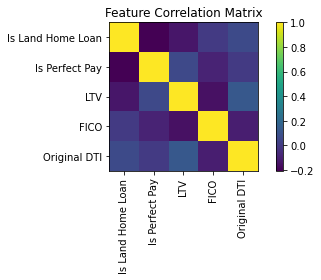

g:\YuemengZhang\Deal Opportunities - Clean\regression.py:342: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if "Other" in X_train[col].values and "Other" not in categories:
g:\YuemengZhang\Deal Opportunities - Clean\regression.py:342: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if "Other" in X_train[col].values and "Other" not in categories:


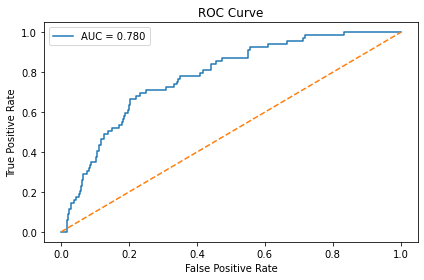

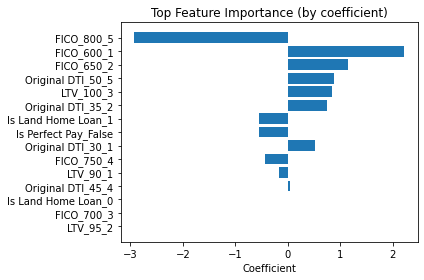

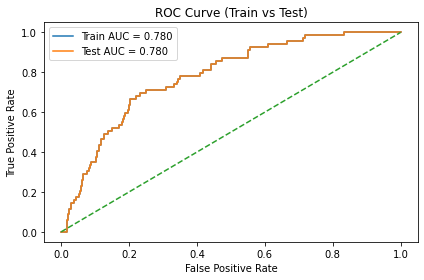

In [195]:
categorical_features = [
                    # "State",
                    "Is Land Home Loan",
                    #  "Region",
                     "Is Perfect Pay"
                       ]

numeric_features = []

spline_features = {
    # "Original Balance": list(np.array([75, 100, 150, 200, 250]) * 1000),
    # "Original Balance": list(np.array([ 75, 100, 125, 150, 175, 200]) * 1000),
    # "Gross Coupon": [7, 8, 9, 10, 11],
    # "Original Amortization Term": [280, 300, 320],
    # "Age (Months)": [0, 5, 10, 15, 20],
    # "NETCOUPON":[7, 8, 9, 10, 11],
    "LTV": [90, 95, 100],
    'FICO': [ 600, 650, 700, 750, 800],
    "Original DTI": [30, 35, 40, 45, 50]
}

manual_baseline = {
    
    }

results = run_model_pipeline(
    df = df_training,
    target_col="Ever D30 or CO @ MOB12",
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    spline_features=spline_features, 
    manual_baseline = manual_baseline,
    model_type="logistic",
    
    test_size=0,
    df_test = df_training.copy(), # using training data as test data for coefficient analysis since we don't have enough data for testing
    
    max_categories=3,
    plot_top_n_features =15,
    # random_state=42,
    
    plot=True,
    output_coef=False,
    output_file_name="Regression_Coefficients.xlsx",
    id_col='Unique ID',
    # adjust_logistic_decision_threshold = 0.125,
    intercept_multiplier = 1
)

In [196]:
# df_chattel.groupby(['DEAL', 'Is_Land_Home_Loan', 'ORIGAMORBALLN']).agg({'UNIQUE_ID': 'count'})

In [197]:
results['coef_df']
# .to_excel("chattel_regression_coefficients.xlsx", index=False)

,Feature,Coefficient,Count,Std Error,Z-Stat,P Value,CI lower,CI upper
6,FICO_600_1,2.215747,210.0800,0.545009,4.065520,4.792545e-05,1.147548,3.283946
7,FICO_650_2,1.152584,276.3800,0.650681,1.771350,7.650247e-02,-0.122727,2.427894
15,FICO_700_3,0.000000,215.9600,NaN,NaN,NaN,NaN,NaN
8,FICO_750_4,-0.425926,139.1600,1.133808,-0.375660,7.071697e-01,-2.648149,1.796296
9,FICO_800_5,-2.930422,54.4200,3.417389,-0.857503,3.911668e-01,-9.628382,3.767537
0,Is Land Home Loan_0,0.000000,722.0000,NaN,NaN,NaN,NaN,NaN
1,Is Land Home Loan_1,-0.555053,174.0000,0.431996,-1.284857,1.988421e-01,-1.401750,0.291643
3,Is Perfect Pay_False,-0.542292,227.0000,0.370725,-1.462789,1.435252e-01,-1.268899,0.184315
2,Is Perfect Pay_True,0.000000,669.0000,NaN,NaN,NaN,NaN,NaN
4,LTV_90_1,-0.167843,190.3560,0.702887,-0.238790,8.112682e-01,-1.545476,1.209791


In [198]:
features = categorical_features + numeric_features + list(spline_features.keys())
output_list = []
for i in range(len(features)+1):
    if i == 0:
        results = run_model_pipeline(
                    df = df_training,
                    target_col="Ever D30 or CO @ MOB12",
                    categorical_features=categorical_features,
                    numeric_features=numeric_features,
                    spline_features=spline_features, 
                    manual_baseline = manual_baseline,
                    model_type="logistic",
                    
                    test_size=0,
                    max_categories=5,
                    plot_top_n_features = 30,
                    # random_state=42,
                    
                    plot=False,
                    output_coef=False,
                    output_file_name="Outputs/Regression_Coefficients.xlsx"
                )
        
        base_auc = results['coef_df'].loc[len(results['coef_df']) - 1, 'Coefficient']
        output_list.append(base_auc)

    else:
        drop_col = features[i-1]

        if drop_col not in df_training.columns:
            print(f"Warning: {drop_col} not found in training data columns.")
        else:
            df_training_ = df_training.drop(columns=drop_col).copy()

        if drop_col in spline_features.keys():
            spline_features_copy = spline_features.copy()
            spline_features_copy.pop(drop_col)
        else:
            spline_features_copy = spline_features.copy()

        
        if drop_col in categorical_features:
            categorical_features_input = categorical_features.copy()
            categorical_features_input.remove(drop_col)
        else:
            categorical_features_input = categorical_features.copy()
        
        results = run_model_pipeline(
            df = df_training_,
            target_col="Ever D30 or CO @ MOB12",
            categorical_features=categorical_features_input,
            numeric_features=numeric_features,
            spline_features=spline_features_copy,
            manual_baseline = manual_baseline,
            model_type="logistic",
            
            test_size=0,
            max_categories=5,
            plot_top_n_features = 30,
            # random_state=42,
            
            plot=False,
            output_coef=False,
            output_file_name="Outputs/Regression_Coefficients.xlsx"
        )
            
        auc = results['coef_df'].loc[len(results['coef_df']) - 1, 'Coefficient']
        output_list.append(auc)

res_df = pd.DataFrame([['All'] + features, output_list]).T
res_df.columns = ['Variables', 'AUC w/o Variable']
res_df['Base AUC'] = base_auc
res_df['AUC Drop'] = res_df['AUC w/o Variable'] - base_auc
res_df = res_df[res_df['Variables'] != 'All']
res_df.sort_values('AUC Drop', ascending=True, inplace=True)
res_df['Ranking'] = res_df['AUC Drop'].rank(method='min', ascending=True).astype(int)
res_df.reset_index(drop=True, inplace=True)

g:\YuemengZhang\Deal Opportunities - Clean\regression.py:342: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if "Other" in X_train[col].values and "Other" not in categories:
g:\YuemengZhang\Deal Opportunities - Clean\regression.py:342: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if "Other" in X_train[col].values and "Other" not in categories:
g:\YuemengZhang\Deal Opportunities - Clean\regression.py:342: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if "Other" in X_train[col].values and "Other" not in categories:
g:\YuemengZhang\Deal Opportunities - Clean\regression.py:342: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if "Other" in X_train[col].values and "Other"

In [199]:
res_df

,Variables,AUC w/o Variable,Base AUC,AUC Drop,Ranking
0,FICO,0.662119,0.779927,-0.117808,1
1,LTV,0.767836,0.779927,-0.012092,2
2,Original DTI,0.769281,0.779927,-0.010646,3
3,Is Perfect Pay,0.775406,0.779927,-0.004521,4
4,Is Land Home Loan,0.776493,0.779927,-0.003435,5


In [ ]:
# res_df.to_excel('auc_drop_analysis.xlsx')

In [ ]:
def plot_in_sample_vs_oos(results, df_training, df_test, df_origination, secondary_y_cols, ever_n_days_past_due, loan_age_cutoff, categorical_col_to_plot = None,
                          orig_bal_col_name = 'AmountFinanced',
                          id_col_name = 'LoanID', 
                          vintage_col_name = 'FundingYearMonth',
                          empirical_col = None,
                          trim_n = 12
                          ):
    secondary_ylabel = secondary_y_cols[0]

    if empirical_col != None:
        in_sample_outputs = df_training[[id_col_name, empirical_col]]
        in_sample_outputs.rename(columns = {empirical_col: 'y_true'},  inplace=True)
    else:
        in_sample_outputs = results['X_train_with_preds']

    oos_result = results['X_test_with_preds']
    # oos_result = oos_result[oos_result['Credit Rating Bucket'] == 'B']

    if orig_bal_col_name not in in_sample_outputs.columns:
        in_sample_outputs = in_sample_outputs.merge(df_training[[id_col_name, vintage_col_name, orig_bal_col_name]], on = id_col_name, how = 'left')
    else:
        in_sample_outputs = in_sample_outputs.merge(df_training[[id_col_name, vintage_col_name]], on = id_col_name, how = 'left')
    in_sample_outputs['Empirical Amount'] = in_sample_outputs.loc[:, 'y_true'] * in_sample_outputs.loc[:, orig_bal_col_name]
    # print(in_sample_outputs.head())

    if orig_bal_col_name not in oos_result.columns:
        oos_result = oos_result.merge(df_test[[id_col_name, vintage_col_name, orig_bal_col_name]], on = id_col_name, how = 'left')
    else:
        oos_result = oos_result.merge(df_test[[id_col_name, vintage_col_name]], on = id_col_name, how = 'left')
    oos_result['Model Results Amount'] = oos_result.loc[:, 'y_pred'] * oos_result.loc[:, orig_bal_col_name]
    output_oos = oos_result.groupby([vintage_col_name]).sum()[[orig_bal_col_name, 'Model Results Amount']]
    output_oos['Model Results'] = output_oos['Model Results Amount'] / output_oos[orig_bal_col_name]

    output = in_sample_outputs.groupby([vintage_col_name]).sum()[[orig_bal_col_name, 'Empirical Amount']]
    output['Empirical'] = output['Empirical Amount'] / output[orig_bal_col_name]
    # output = output.apply(trim_last_n, n=trim_n )

    output = output.join(output_oos, how='outer', lsuffix='_in_sample', rsuffix='_oos')

    if categorical_col_to_plot:
        percentage_tables = get_wt_distribution(df_origination, 
                                                    secondary_y_cols[0],
                                                    vintage = vintage_col_name,
                                                    weight_by = orig_bal_col_name, show_total_origination = False, format_pct = False).T
        output = output.join(percentage_tables[[categorical_col_to_plot]], how='outer')        
        output_plot = output[['Empirical', 'Model Results'] + [categorical_col_to_plot]]  
        secondary_ylabel = '{} = {} %'.format(secondary_y_cols[0], 'Yes' if categorical_col_to_plot == 1 else categorical_col_to_plot)
        secondary_y_cols = [categorical_col_to_plot]   
        secondary_percentage = True                               
    else:
        wa_tables = groupby_weighted_avg(df_origination, groupby_col = vintage_col_name, cols = secondary_y_cols, weight_col = orig_bal_col_name)
        output = output.join(wa_tables, how='outer')    

        output_plot = output[['Empirical', 'Model Results'] + secondary_y_cols]
        secondary_percentage = False

    if secondary_y_cols:
        plot_finance_style(
                            # everdp_plot,
                            output_plot, 
                            title="Ever D{:.0f} at MOB {:.0f} vs {}".format(ever_n_days_past_due, loan_age_cutoff, secondary_ylabel ),
                            ylabel="Ever D{:.0f} at MOB {:.0f}".format(ever_n_days_past_due, loan_age_cutoff), data_labels=False,
                            secondary_y_cols=secondary_y_cols,   # columns on right axis
                            secondary_ylabel = secondary_ylabel,
                            percentage=True,
                            secondary_percentage=secondary_percentage,
                            use_custom_colors=False,
                            linestyles_inputs = ['-', '-', '--']
                            )
    else:
        plot_finance_style(
                            # everdp_plot,
                            output_plot, 
                            title="Ever D{:.0f} at MOB {:.0f}".format(ever_n_days_past_due, loan_age_cutoff),
                            ylabel="Ever D{:.0f} at MOB {:.0f}".format(ever_n_days_past_due, loan_age_cutoff), data_labels=False,
                            # secondary_y_cols=secondary_y_cols,   # columns on right axis
                            # secondary_ylabel = secondary_ylabel,
                            percentage=True,
                            secondary_percentage=secondary_percentage,
                            use_custom_colors=False,
                            linestyles_inputs = ['-', '-', '--']
                            )

    return output_plot


In [1051]:
# ever_dq_co_select.head()

C:\Users\YuemengZhang\AppData\Local\Temp\ipykernel_60836\1594906036.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  in_sample_outputs.rename(columns = {empirical_col: 'y_true'},  inplace=True)


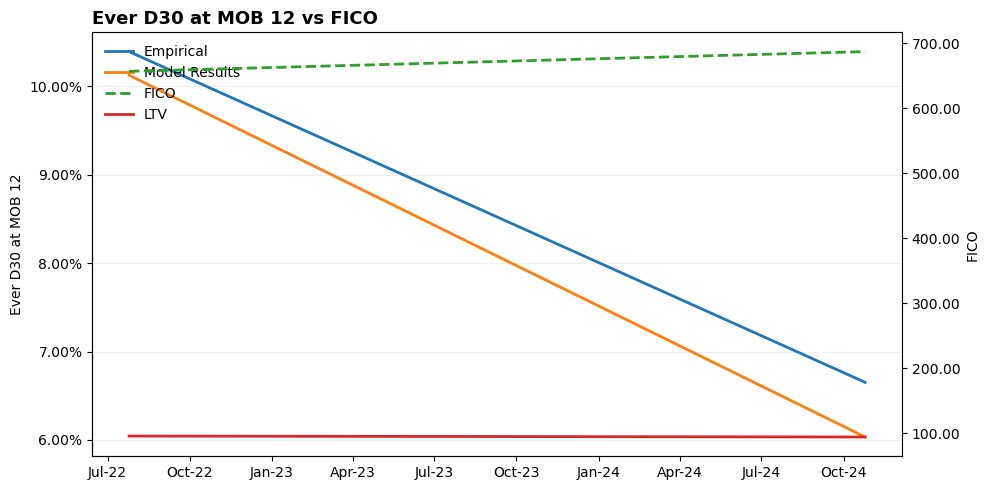

In [1052]:
res = plot_in_sample_vs_oos(results, df_training, df_training, df_training, ['FICO', 'LTV'], 30, 12, categorical_col_to_plot = None,
                          orig_bal_col_name = 'Original Balance',
                          id_col_name = 'Unique ID', 
                          vintage_col_name = 'Deal Close Vintage',
                          empirical_col = 'Ever D30 or CO @ MOB12',
                          trim_n  = 0)

In [1053]:
res = res.join(df_training.groupby('Deal Close Vintage')['Original Balance'].sum())

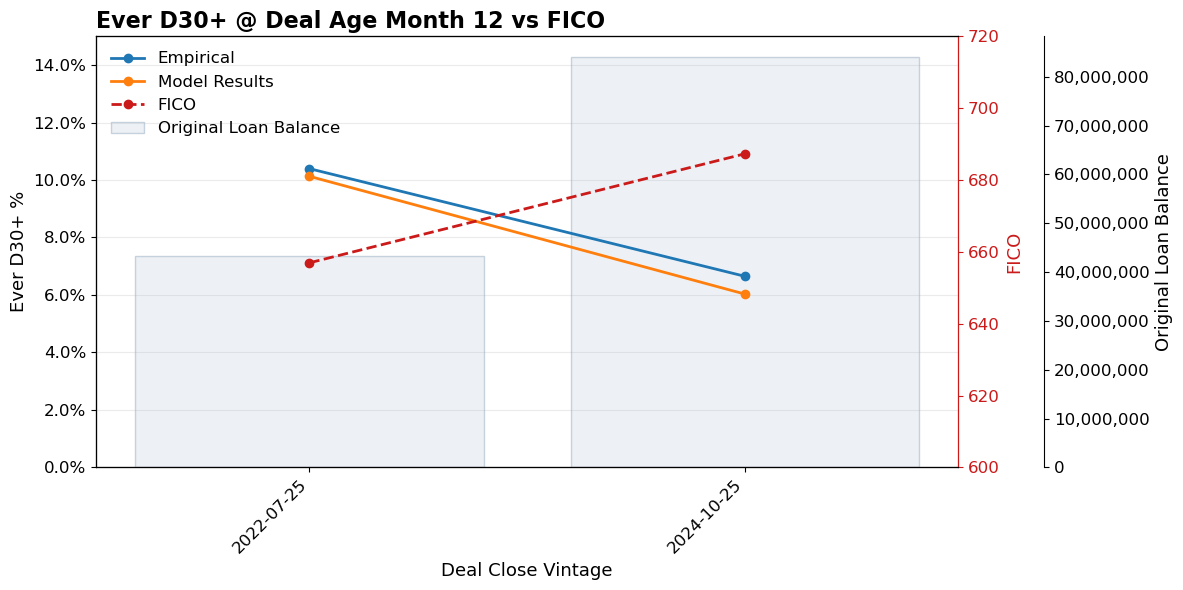

In [1054]:
everd30_charts = plot_metric_vs_volume(
                                        res.reset_index(),
                                        value_cols=['Empirical', 'Model Results'],
                                        right_value_cols=['FICO'],
                                        volume_col=['Original Balance'],
                                        volume_color=["#d9e2ec"],
                                                    #   , "#f2c57c"],
                                        volume_edge_color=["#8aa2b8"],
                                                        #    , "#b88932"],

                                        x_col=vintage_col_name,
                                        title="Ever D{}+ @ Deal Age Month 12 vs FICO".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="FICO",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors=["#cb1a1a"],
                                        volume_display="right_axis",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=0.15,
                                        right_y_min = 600,
                                        right_y_max = 720
                                    )

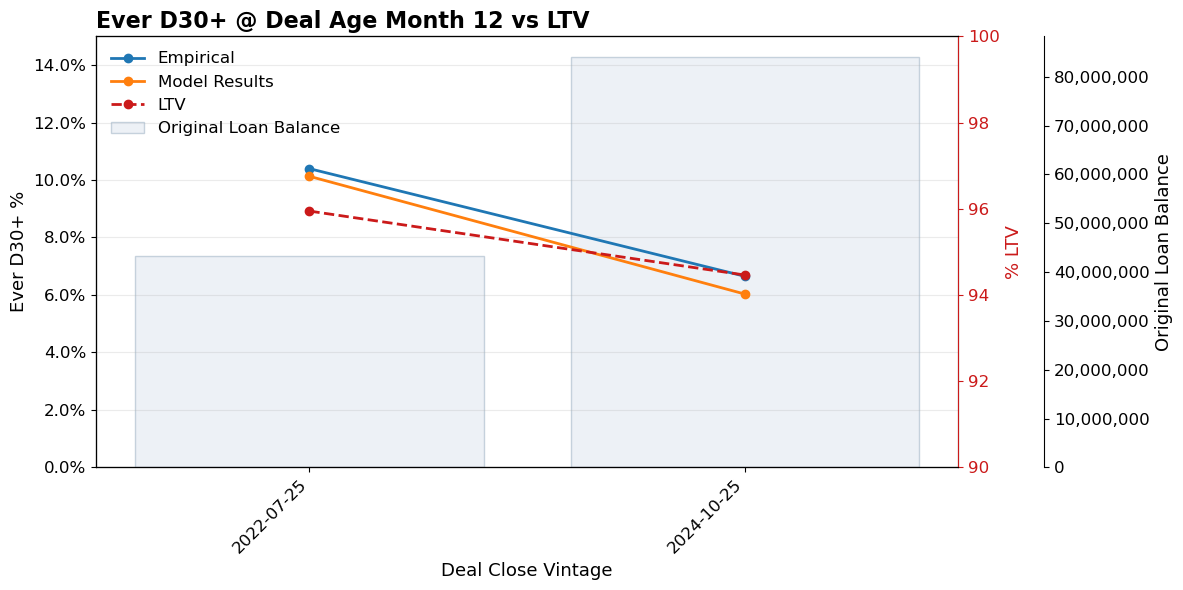

In [1058]:
everd30_charts = plot_metric_vs_volume(
                                        res.reset_index(),
                                        value_cols=['Empirical', 'Model Results'],
                                        right_value_cols=['LTV'],
                                        volume_col=['Original Balance'],
                                        volume_color=["#d9e2ec"],
                                                    #   , "#f2c57c"],
                                        volume_edge_color=["#8aa2b8"],
                                                        #    , "#b88932"],

                                        x_col=vintage_col_name,
                                        title="Ever D{}+ @ Deal Age Month 12 vs LTV".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="% LTV",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="integer",
                                        right_colors=["#cb1a1a"],
                                        volume_display="right_axis",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=0.15,
                                        right_y_min = 90,
                                        right_y_max = 100
                                    )

In [1056]:
df_training['Land Home Loan Balance'] = df_training['Is Land Home Loan'] * df_training['Original Balance']
df_append = df_training.groupby('Deal Close Vintage').agg({'Original Balance': 'sum', 'Land Home Loan Balance': 'sum'})
df_append['Land Home Loan %'] = df_append['Land Home Loan Balance'] / df_append['Original Balance']
df_append['Chattel %'] = 1 - df_append['Land Home Loan %']
res = res.join(df_append[['Land Home Loan %', 'Chattel %']]) 

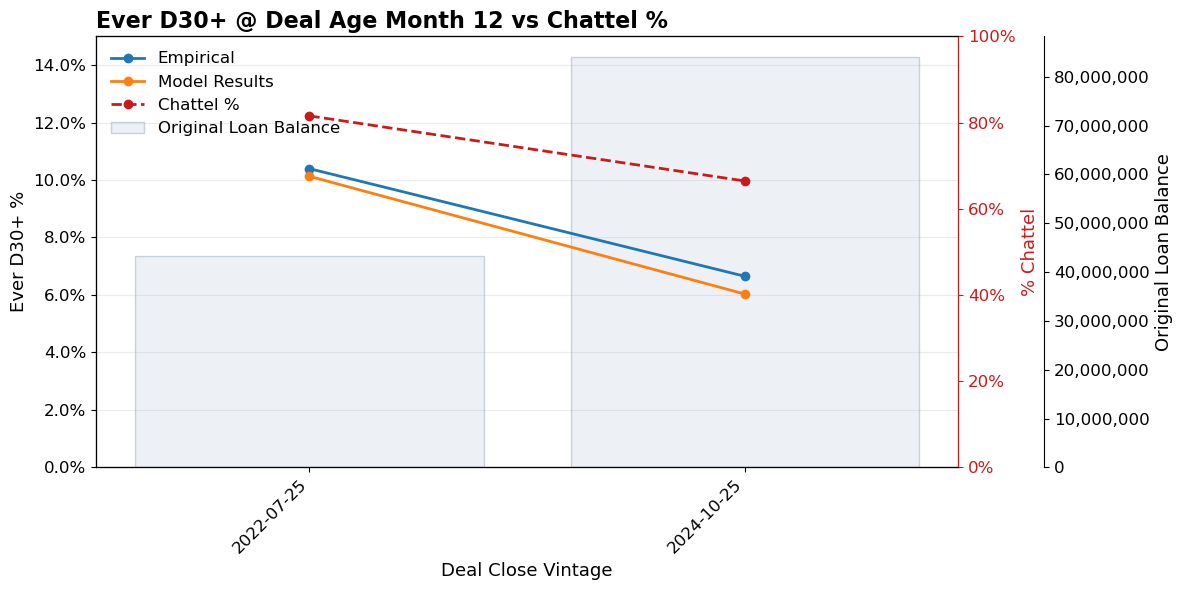

In [1064]:
everd30_charts = plot_metric_vs_volume(
                                        res.reset_index(),
                                        value_cols=['Empirical', 'Model Results'],
                                        right_value_cols=['Chattel %'],
                                        volume_col=['Original Balance'],
                                        volume_color=["#d9e2ec"],
                                                    #   , "#f2c57c"],
                                        volume_edge_color=["#8aa2b8"],
                                                        #    , "#b88932"],

                                        x_col=vintage_col_name,
                                        title="Ever D{}+ @ Deal Age Month 12 vs Chattel %".format(dpd_num),
                                        x_label=format_column_label(vintage_col_name),
                                        value_ylabel="Ever D{}+ %".format(dpd_num),
                                        right_ylabel="% Chattel",
                                        volume_ylabel="Original Loan Balance",
                                        value_y_formatter="percent",
                                        right_y_formatter="percent",
                                        right_colors=["#cb1a1a"],
                                        volume_display="right_axis",  # switch to "right_axis" or "background" or "none"
                                        figsize=(12, 6),
                                        show=True,
                                        value_y_min=0,
                                        value_y_max=0.15,
                                        right_y_min =0,
                                        right_y_max = 1
                                    )